In [13]:
from google.colab import drive
drive.mount('/content/drive')

import sys, pickle

ROOT = '/content/drive/MyDrive/CW_Folder_UG'
sys.path.insert(0, f'{ROOT}/Code')

from utils import *
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

MODELS_DIR = f'{ROOT}/Models'
os.makedirs(MODELS_DIR, exist_ok=True)

with open(f'{ROOT}/Code/data_splits.pkl', 'rb') as f:
    d = pickle.load(f)
train_paths, train_labels = d['train_paths'], d['train_labels']
test_paths,  test_labels  = d['test_paths'],  d['test_labels']
print(f'Train: {len(train_paths)}  Test: {len(test_paths)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 13300  Test: 850


In [14]:
import shutil, os

LOCAL_ROOT = '/tmp/CW_data'

if not os.path.exists(LOCAL_ROOT):
    print("Copying dataset to local SSD.")
    shutil.copytree(ROOT, LOCAL_ROOT)
    print("Done.")
else:
    print("Local copy already exists, skipping.")

# Remap paths from Drive to local SSD
def remap(paths, src=ROOT, dst=LOCAL_ROOT):
    return [p.replace(src, dst) for p in paths]

train_paths = remap(train_paths)
test_paths  = remap(test_paths)
print(f"Paths remapped to {LOCAL_ROOT}")

Local copy already exists, skipping.
Paths remapped to /tmp/CW_data


In [15]:
print("Extracting HOG...")
X_hog_all = batch_extract(train_paths, extract_hog, "HOG-train")
X_hog_test = batch_extract(test_paths, extract_hog, "HOG-test")

print("Extracting LBP...")
X_lbp_all = batch_extract(train_paths, extract_lbp, "LBP-train")
X_lbp_test = batch_extract(test_paths, extract_lbp, "LBP-test")

print("Extracting HOG+LBP...")
X_both_all  = np.hstack([X_hog_all, X_lbp_all])
X_both_test = np.hstack([X_hog_test, X_lbp_test])

y_all  = np.array(train_labels)
y_test = np.array(test_labels)

# Save features (avoids re-extracting)
np.savez(f'{ROOT}/Code/features_track1.npz',
         X_hog_all=X_hog_all, X_hog_test=X_hog_test,
         X_lbp_all=X_lbp_all, X_lbp_test=X_lbp_test,
         X_both_all=X_both_all, X_both_test=X_both_test,
         y_all=y_all, y_test=y_test)
print("Features saved.")

print(f'HOG dim: {X_hog_all.shape[1]}  LBP dim: {X_lbp_all.shape[1]}  HOG+LBP dim: {X_both_all.shape[1]}')

Extracting HOG...
  HOG-train: 0/13300
  HOG-train: 1000/13300
  HOG-train: 2000/13300
  HOG-train: 3000/13300
  HOG-train: 4000/13300
  HOG-train: 5000/13300
  HOG-train: 6000/13300
  HOG-train: 7000/13300
  HOG-train: 8000/13300
  HOG-train: 9000/13300
  HOG-train: 10000/13300
  HOG-train: 11000/13300
  HOG-train: 12000/13300
  HOG-train: 13000/13300
  HOG-test: 0/850
Extracting LBP...
  LBP-train: 0/13300
  LBP-train: 1000/13300
  LBP-train: 2000/13300
  LBP-train: 3000/13300
  LBP-train: 4000/13300
  LBP-train: 5000/13300
  LBP-train: 6000/13300
  LBP-train: 7000/13300
  LBP-train: 8000/13300
  LBP-train: 9000/13300
  LBP-train: 10000/13300
  LBP-train: 11000/13300
  LBP-train: 12000/13300
  LBP-train: 13000/13300
  LBP-test: 0/850
Extracting HOG+LBP...
Features saved.
HOG dim: 1764  LBP dim: 26  HOG+LBP dim: 1790


In [16]:
(X_hog_tr,  X_hog_val,
 X_lbp_tr,  X_lbp_val,
 X_both_tr, X_both_val,
 y_tr, y_val) = train_test_split(
    X_hog_all, X_lbp_all, X_both_all, y_all,
    test_size=0.1, stratify=y_all, random_state=SEED
)

# Normalise features — scaler fit on train only to avoid data leakage
X_hog_tr_s,  X_hog_val_s,  X_hog_te_s,  sc_hog  = fit_scaler(X_hog_tr,  X_hog_val,  X_hog_test)
X_lbp_tr_s,  X_lbp_val_s,  X_lbp_te_s,  sc_lbp  = fit_scaler(X_lbp_tr,  X_lbp_val,  X_lbp_test)
X_both_tr_s, X_both_val_s, X_both_te_s, sc_both = fit_scaler(X_both_tr, X_both_val, X_both_test)

print(f'Train: {len(y_tr)}  Val: {len(y_val)}  Test: {len(y_test)}')

Train: 11970  Val: 1330  Test: 850


In [17]:
knn  = lambda: KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)
lsvm = lambda: svm.SVC(kernel='linear', class_weight='balanced',
                        random_state=SEED, max_iter=5000)
mlp  = lambda: MLPClassifier(hidden_layer_sizes=(512, 256), activation='relu',
                              solver='adam', max_iter=100,
                              early_stopping=True, random_state=SEED)
rf   = lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                      n_jobs=-1, random_state=SEED)

EXPERIMENTS = {
    'HOG+KNN':          (knn(),  X_hog_tr_s,  X_hog_val_s,  X_hog_te_s),
    'LBP+KNN':          (knn(),  X_lbp_tr_s,  X_lbp_val_s,  X_lbp_te_s),
    'HOG+LBP+KNN':      (knn(),  X_both_tr_s, X_both_val_s, X_both_te_s),
    'HOG+LinearSVM':    (lsvm(), X_hog_tr_s,  X_hog_val_s,  X_hog_te_s),
    'LBP+LinearSVM':    (lsvm(), X_lbp_tr_s,  X_lbp_val_s,  X_lbp_te_s),
    'HOG+LBP+LinearSVM':(lsvm(), X_both_tr_s, X_both_val_s, X_both_te_s),
    'HOG+MLP':          (mlp(),  X_hog_tr_s,  X_hog_val_s,  X_hog_te_s),
    'LBP+MLP':          (mlp(),  X_lbp_tr_s,  X_lbp_val_s,  X_lbp_te_s),
    'HOG+LBP+MLP':      (mlp(),  X_both_tr_s, X_both_val_s, X_both_te_s),
    'HOG+RF':           (rf(),   X_hog_tr_s,  X_hog_val_s,  X_hog_te_s),
    'LBP+RF':           (rf(),   X_lbp_tr_s,  X_lbp_val_s,  X_lbp_te_s),
    'HOG+LBP+RF':       (rf(),   X_both_tr_s, X_both_val_s, X_both_te_s),
}

In [18]:
results = {}

for name, (clf, Xtr, Xval, Xte) in EXPERIMENTS.items():
    print(f'Training {name}...')
    t0 = time.time()
    clf.fit(Xtr, y_tr)
    tt = time.time() - t0

    val_pred  = clf.predict(Xval)
    test_pred = clf.predict(Xte)
    val_acc   = accuracy_score(y_val, val_pred)
    test_acc  = accuracy_score(y_test, test_pred)

    path = f'{MODELS_DIR}/track1_{name.replace("+", "_")}.pkl'
    joblib.dump(clf, path)

    results[name] = {
        'val_acc': val_acc, 'test_acc': test_acc,
        'train_time': tt, 'test_preds': test_pred, 'path': path
    }
    print(f'  val={val_acc:.4f}  test={test_acc:.4f}  time={tt:.1f}s')

Training HOG+KNN...
  val=0.6496  test=0.6435  time=0.0s
Training LBP+KNN...
  val=0.4947  test=0.4800  time=0.0s
Training HOG+LBP+KNN...
  val=0.6541  test=0.6412  time=0.0s
Training HOG+LinearSVM...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  val=0.5797  test=0.5953  time=116.1s
Training LBP+LinearSVM...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  val=0.4158  test=0.3824  time=6.5s
Training HOG+LBP+LinearSVM...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  val=0.6015  test=0.5894  time=122.8s
Training HOG+MLP...
  val=0.7331  test=0.7482  time=114.5s
Training LBP+MLP...
  val=0.5549  test=0.5506  time=17.5s
Training HOG+LBP+MLP...
  val=0.7346  test=0.7506  time=119.5s
Training HOG+RF...
  val=0.6677  test=0.6788  time=217.6s
Training LBP+RF...
  val=0.5586  test=0.5224  time=19.5s
Training HOG+LBP+RF...
  val=0.6767  test=0.6718  time=223.9s


In [19]:
print(f"{'Model':<22} {'Val Acc':>9} {'Test Acc':>10} {'Time(s)':>9}")
print('─' * 54)
for name, r in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f"{name:<22} {r['val_acc']:>9.4f} {r['test_acc']:>10.4f} {r['train_time']:>9.1f}")

best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f"Best Track 1: {best_name}  (test acc={results[best_name]['test_acc']:.4f})")

Model                    Val Acc   Test Acc   Time(s)
──────────────────────────────────────────────────────
HOG+LBP+MLP               0.7346     0.7506     119.5
HOG+MLP                   0.7331     0.7482     114.5
HOG+RF                    0.6677     0.6788     217.6
HOG+LBP+RF                0.6767     0.6718     223.9
HOG+KNN                   0.6496     0.6435       0.0
HOG+LBP+KNN               0.6541     0.6412       0.0
HOG+LinearSVM             0.5797     0.5953     116.1
HOG+LBP+LinearSVM         0.6015     0.5894     122.8
LBP+MLP                   0.5549     0.5506      17.5
LBP+RF                    0.5586     0.5224      19.5
LBP+KNN                   0.4947     0.4800       0.0
LBP+LinearSVM             0.4158     0.3824       6.5
Best Track 1: HOG+LBP+MLP  (test acc=0.7506)


In [20]:
for name, r in results.items():
    evaluate(name, y_test, r['test_preds'], r['train_time'], r['path'])

Model: HOG+KNN
Training Time: 0.0 seconds
Model Size: 161.19 MB
Accuracy: 0.6435
Classification Report:
              precision    recall  f1-score   support

       Child       0.88      0.66      0.75       150
       Young       0.73      0.76      0.75       350
 Middle-Aged       0.48      0.49      0.49       200
      Senior       0.49      0.55      0.52       150

    accuracy                           0.64       850
   macro avg       0.65      0.62      0.63       850
weighted avg       0.66      0.64      0.65       850

Model: LBP+KNN
Training Time: 0.0 seconds
Model Size: 2.47 MB
Accuracy: 0.4800
Classification Report:
              precision    recall  f1-score   support

       Child       0.42      0.39      0.41       150
       Young       0.54      0.65      0.59       350
 Middle-Aged       0.34      0.29      0.31       200
      Senior       0.56      0.42      0.48       150

    accuracy                           0.48       850
   macro avg       0.46      0.44

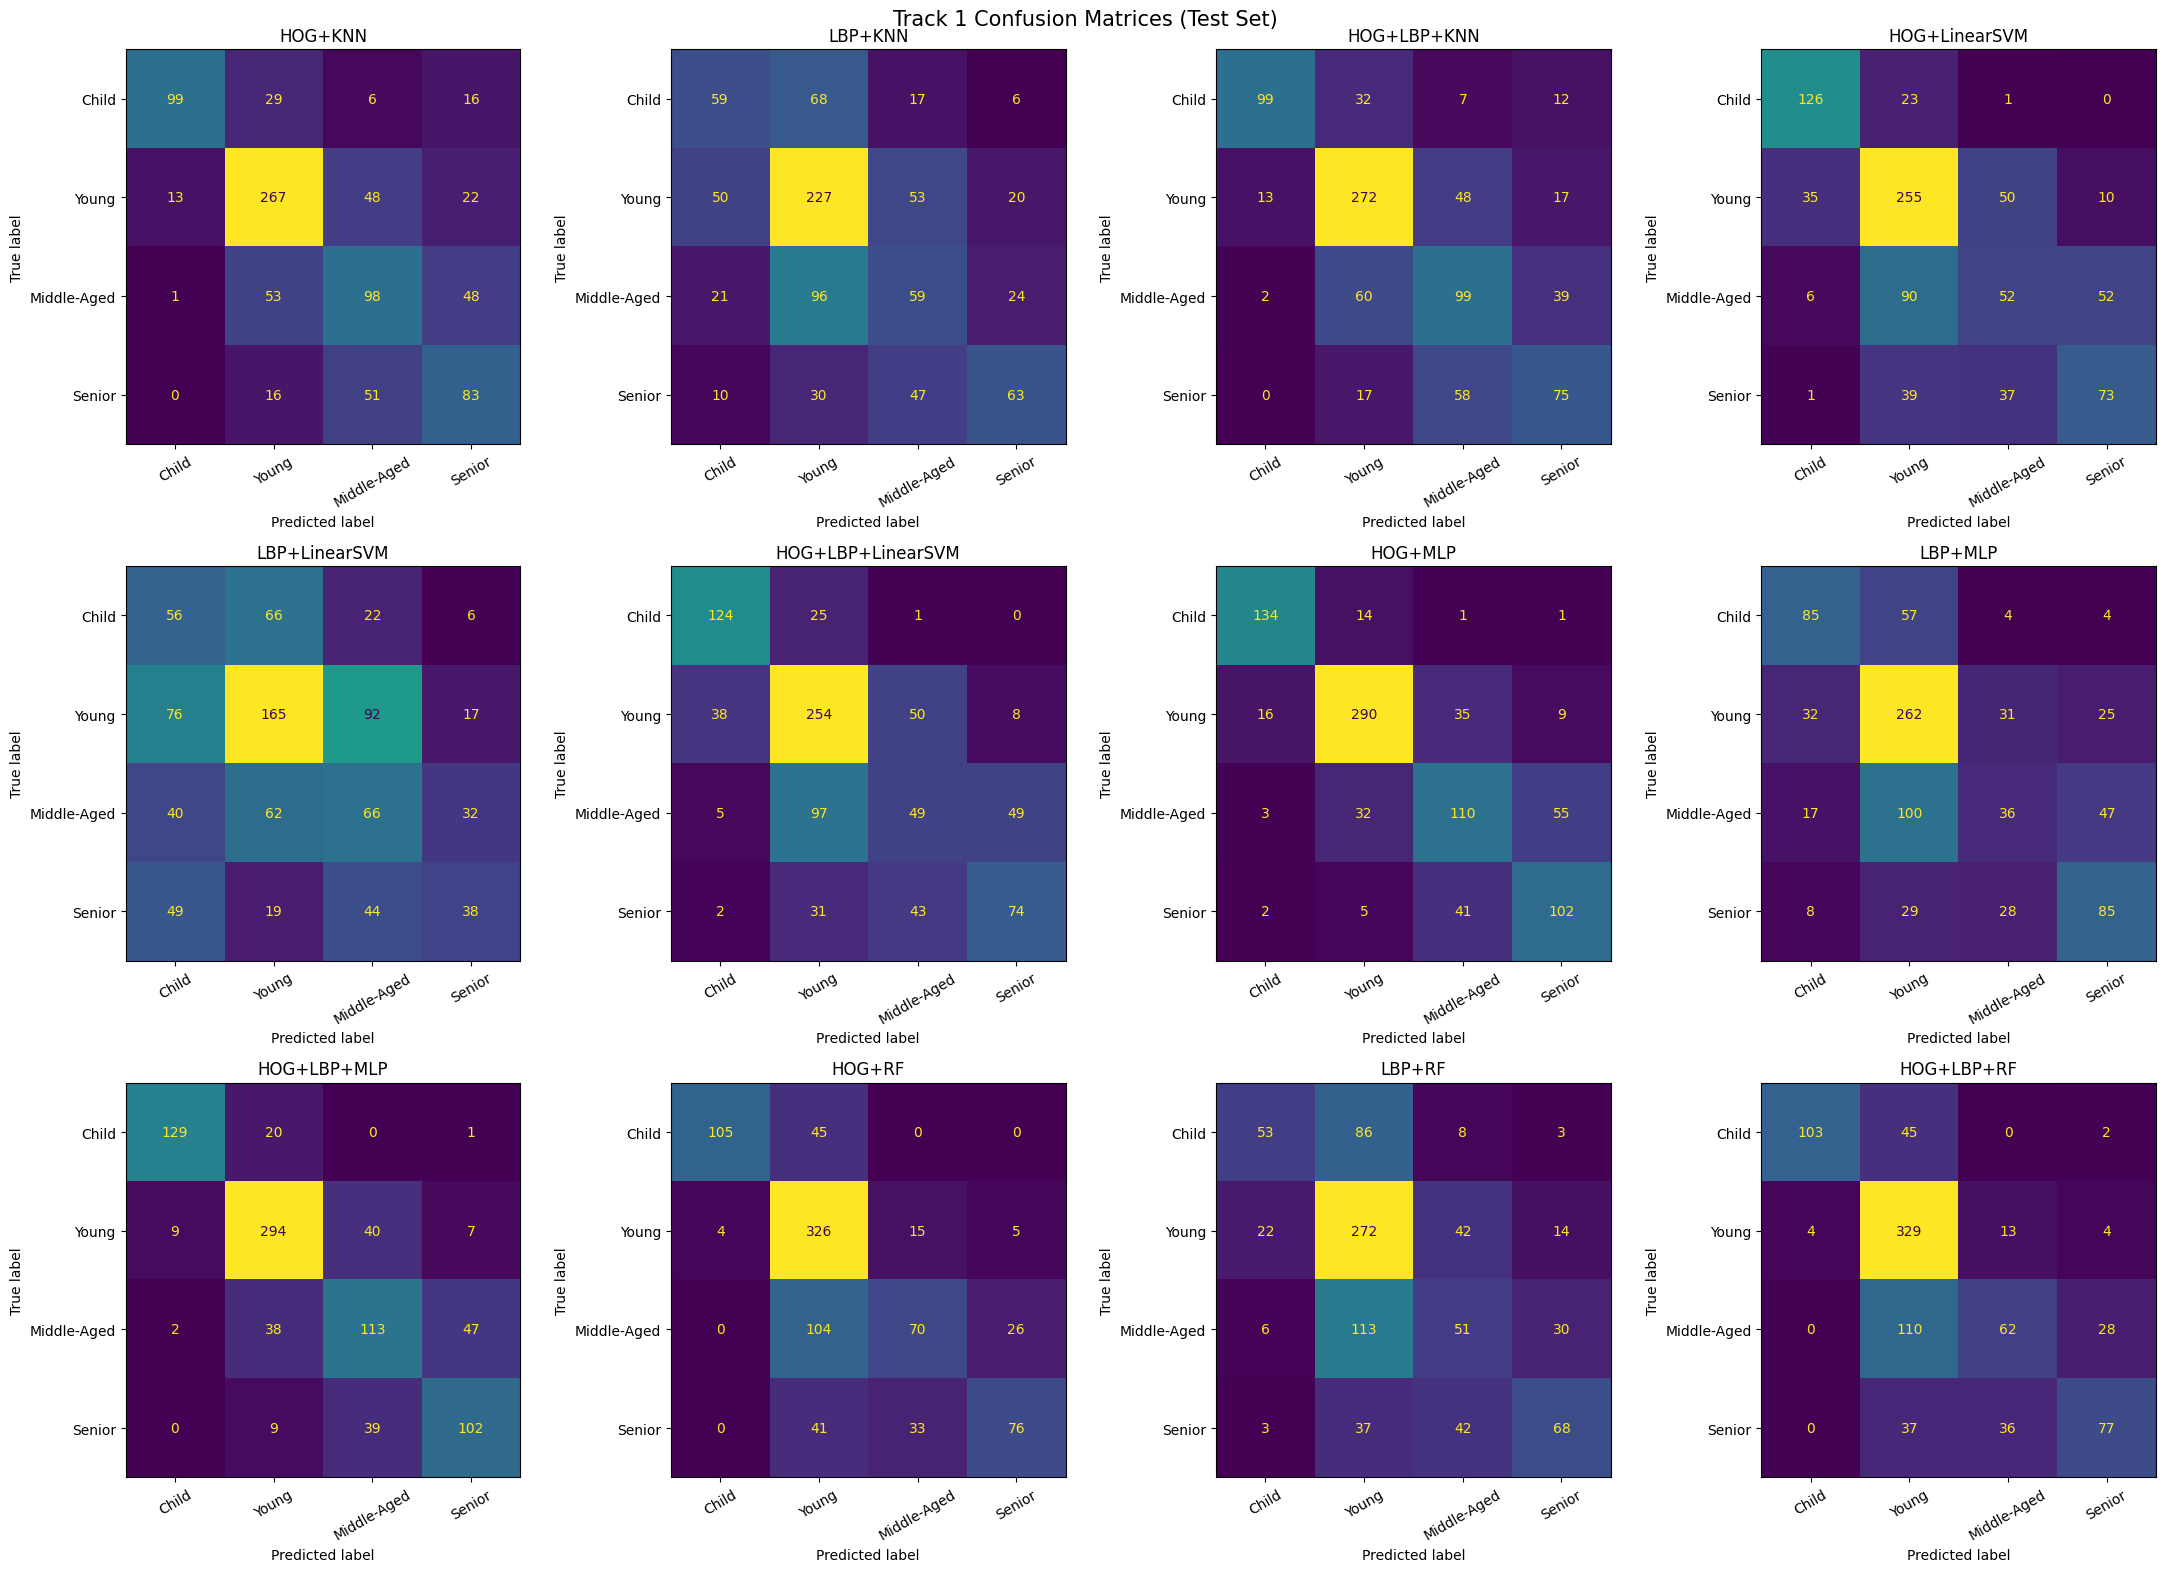

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
for ax, name in zip(axes.flatten(), EXPERIMENTS.keys()):
    plot_confusion_matrix(name, y_test, results[name]['test_preds'], ax=ax)
plt.suptitle('Track 1 Confusion Matrices (Test Set)', fontsize=15)
plt.tight_layout()
plt.show()

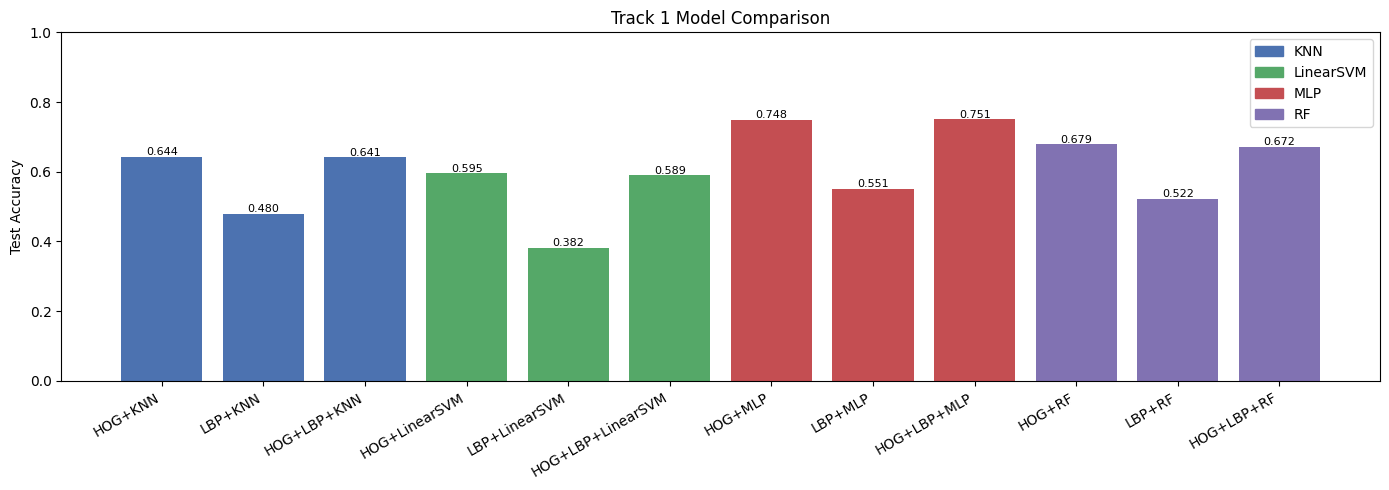

In [22]:
names = list(results.keys())
accs  = [results[n]['test_acc'] for n in names]
colors = ['#4C72B0']*3 + ['#55A868']*3 + ['#C44E52']*3 + ['#8172B2']*3

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, accs, color=colors)
ax.set_ylim(0, 1); ax.set_ylabel('Test Accuracy')
ax.set_title('Track 1 Model Comparison')
plt.xticks(rotation=30, ha='right')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{acc:.3f}',
            ha='center', fontsize=8)
handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(['#4C72B0','#55A868','#C44E52','#8172B2'],
                           ['KNN','LinearSVM','MLP','RF'])]
ax.legend(handles=handles)
plt.tight_layout(); plt.show()

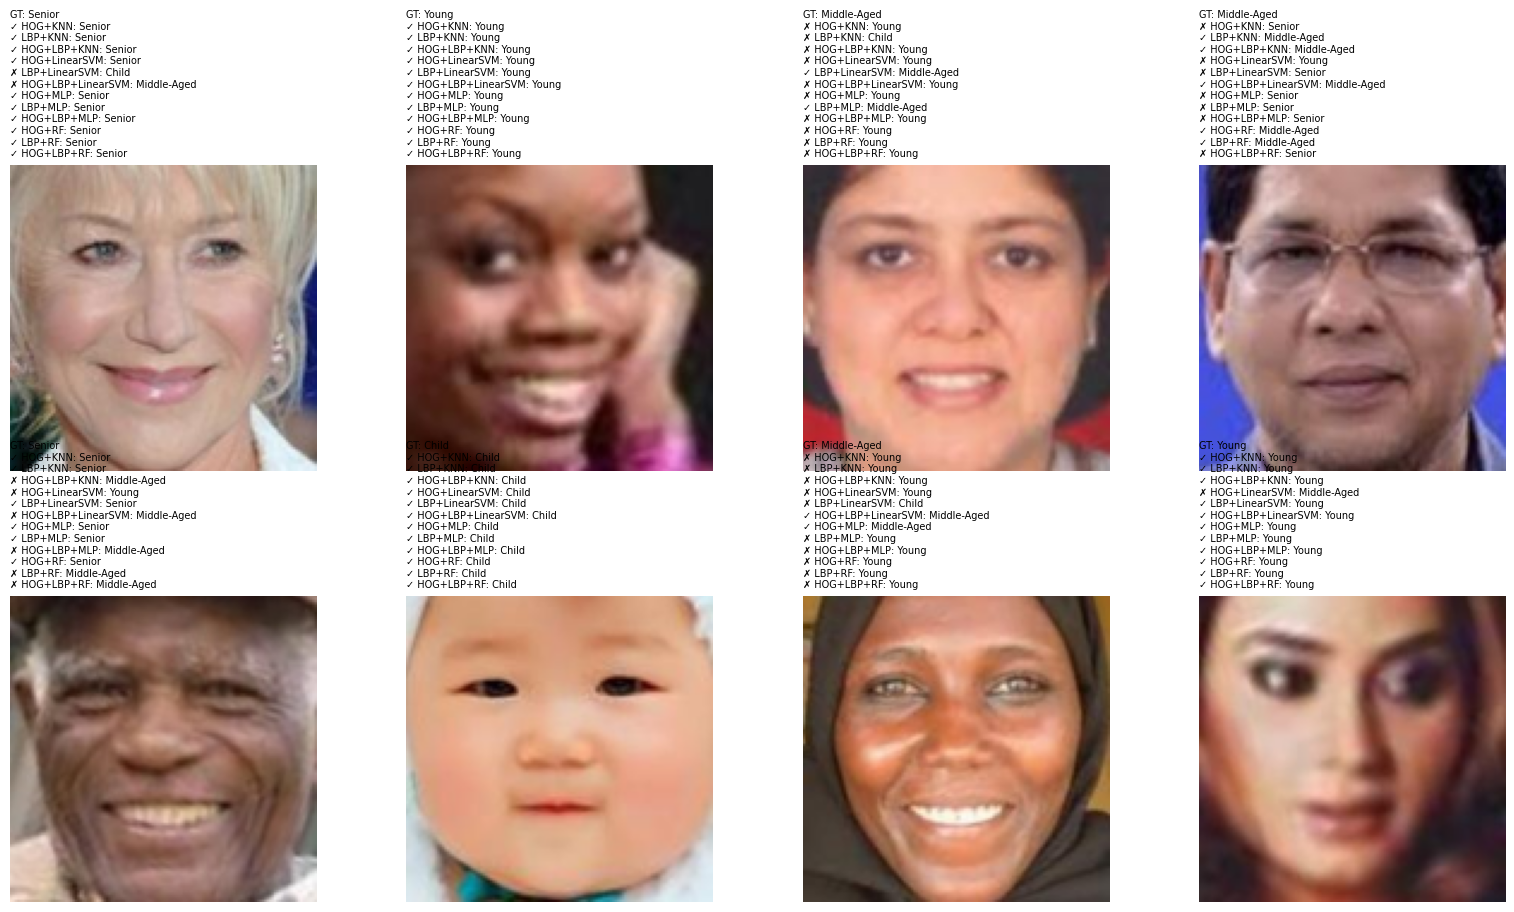

In [23]:
qualitative_grid(test_paths, test_labels,
                 {n: results[n]['test_preds'] for n in results}, n=8)

In [24]:
with open(f'{ROOT}/Code/track1_results.pkl', 'wb') as f:
    pickle.dump({
        'results':   results,
        'best_name': best_name,
        'scalers':   {'hog': sc_hog, 'lbp': sc_lbp, 'both': sc_both}
    }, f)
print('Track 1 results saved')

Track 1 results saved
